Paso 1: Importar librerías

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models

print("Librerías importadas correctamente")
print("TensorFlow:", tf.__version__)

Librerías importadas correctamente
TensorFlow: 2.20.0


Paso 2: Cargar el dataset CIFAR-10

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

print("Dataset cargado correctamente")
print("Imágenes de entrenamiento:", x_train.shape)
print("Imágenes de prueba:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 824s 5us/step
Dataset cargado correctamente
Imágenes de entrenamiento: (50000, 32, 32, 3)
Imágenes de prueba: (10000, 32, 32, 3)


Paso 3: Definir las clases

In [3]:
class_names = [
    "Avión",
    "Automóvil",
    "Pájaro",
    "Gato",
    "Ciervo",
    "Perro",
    "Rana",
    "Caballo",
    "Barco",
    "Camión"
]

for indice, clase in enumerate(class_names):
    print(indice, "=", clase)

0 = Avión
1 = Automóvil
2 = Pájaro
3 = Gato
4 = Ciervo
5 = Perro
6 = Rana
7 = Caballo
8 = Barco
9 = Camión


Paso 4: Mostrar algunas imágenes

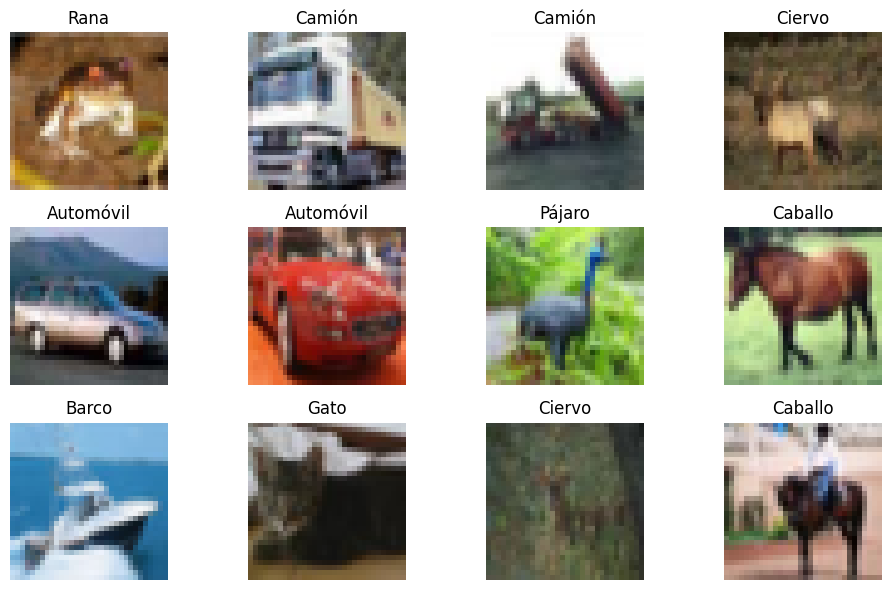

In [4]:
plt.figure(figsize=(10, 6))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.tight_layout()
plt.show()

Paso 5: Normalizar las imágenes

In [5]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Imágenes normalizadas correctamente")
print("Valor mínimo:", x_train.min())
print("Valor máximo:", x_train.max())

Imágenes normalizadas correctamente
Valor mínimo: 0.0
Valor máximo: 1.0


Paso 6: Crear la CNN básica

In [6]:
model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),

    layers.Conv2D(
        32,
        (3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D(
        (2, 2)
    ),

    layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D(
        (2, 2)
    ),

    layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    layers.Flatten(),

    layers.Dense(
        64,
        activation="relu"
    ),

    layers.Dense(
        10,
        activation="softmax"
    )
])

print("Modelo CNN creado correctamente")

Modelo CNN creado correctamente


Paso 7: Ver la estructura del modelo

In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

Paso 8: Compilar

In [8]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Modelo compilado correctamente")

Modelo compilado correctamente


Paso 9: Entrenar

In [15]:
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 56s 90ms/step - accuracy: 0.6370 - loss: 1.0362 - val_accuracy: 0.6386 - val_loss: 1.0286
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 57s 91ms/step - accuracy: 0.6641 - loss: 0.9514 - val_accuracy: 0.6379 - val_loss: 1.0234
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 85s 97ms/step - accuracy: 0.6883 - loss: 0.8927 - val_accuracy: 0.6616 - val_loss: 0.9801
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 79s 92ms/step - accuracy: 0.7062 - loss: 0.8364 - val_accuracy: 0.6771 - val_loss: 0.9258
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 57s 91ms/step - accuracy: 0.7253 - loss: 0.7859 - val_accuracy: 0.6890 - val_loss: 0.8962


Paso 10: Evaluar

In [16]:
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test
)

print(
    f"Precisión en prueba: {test_accuracy * 100:.2f}%"
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.6872 - loss: 0.9055
Precisión en prueba: 68.72%


Paso 11: Guardar el modelo

In [17]:
model.save(
    "/content/modelo_cifar10.keras"
)

print("Modelo guardado correctamente")

Modelo guardado correctamente


Paso 12: probar una predicción

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step


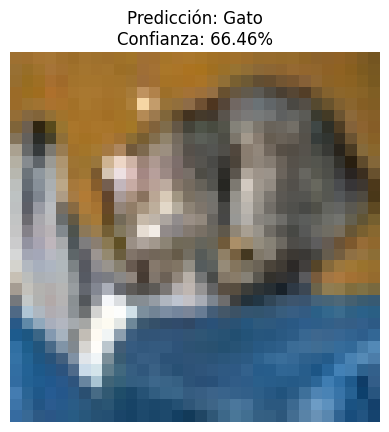

Predicción: Gato
Confianza: 66.46%
Clase real: Gato


In [18]:
predicciones = model.predict(x_test)

indice = 0

prediccion = np.argmax(predicciones[indice])
confianza = np.max(predicciones[indice]) * 100
clase_real = y_test[indice][0]

plt.imshow(x_test[indice])
plt.axis("off")

plt.title(
    f"Predicción: {class_names[prediccion]}\n"
    f"Confianza: {confianza:.2f}%"
)

plt.show()

print("Predicción:", class_names[prediccion])
print(f"Confianza: {confianza:.2f}%")
print("Clase real:", class_names[clase_real])